# PTF Exploratory Data Analysis

This notebook explores the cleaned PTF dataset prepared from EPİAŞ market data.

## Objectives

- Understand the structure and quality of the dataset
- Check time continuity and missing timestamps
- Analyze the distribution of PTF values
- Explore hourly, daily, weekly, and monthly patterns
- Detect outliers and unusual behavior
- Inspect autocorrelation and seasonality signals
- Prepare insights for feature engineering and modeling

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

DATA_PATH = Path("../data/processed/ptf/ptf_processed.parquet")

## Load the dataset

We start by loading the processed PTF dataset and inspecting its basic structure.

In [23]:
df = pd.read_parquet(DATA_PATH).copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (72504, 9)


,date,hour,ptf,priceusd,priceeur,_chunk_start,_chunk_end,year,month
0,2018-01-01 00:00:00+03:00,00:00,207.60,55.04,45.97,2018-01-01,2018-01-07,2018,1
1,2018-01-01 01:00:00+03:00,01:00,205.34,54.44,45.47,2018-01-01,2018-01-07,2018,1
2,2018-01-01 02:00:00+03:00,02:00,164.94,43.73,36.53,2018-01-01,2018-01-07,2018,1
3,2018-01-01 03:00:00+03:00,03:00,154.52,40.97,34.22,2018-01-01,2018-01-07,2018,1
4,2018-01-01 04:00:00+03:00,04:00,112.64,29.86,24.95,2018-01-01,2018-01-07,2018,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72504 entries, 0 to 72503
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype                                
---  ------        --------------  -----                                
 0   date          72504 non-null  datetime64[ns, pytz.FixedOffset(180)]
 1   hour          72504 non-null  object                               
 2   ptf           72504 non-null  float64                              
 3   priceusd      72504 non-null  float64                              
 4   priceeur      72504 non-null  float64                              
 5   _chunk_start  72504 non-null  object                               
 6   _chunk_end    72504 non-null  object                               
 7   year          72504 non-null  int32                                
 8   month         72504 non-null  int32                                
dtypes: datetime64[ns, pytz.FixedOffset(180)](1), float64(3), int32(2), object(3)
memory 

In [25]:
df.describe(include="all")

,date,hour,ptf,priceusd,priceeur,_chunk_start,_chunk_end,year,month
count,72504,72504,72504.000000,72504.000000,72504.000000,72504,72504,72504.000000,72504.000000
unique,NaN,24,NaN,NaN,NaN,432,432,NaN,NaN
top,NaN,00:00,NaN,NaN,NaN,2018-01-01,2018-01-07,NaN,NaN
freq,NaN,3021,NaN,NaN,NaN,168,168,NaN,NaN
mean,2022-02-19 11:30:00+03:00,NaN,1378.258260,70.204936,63.800423,NaN,NaN,2021.647799,6.380669
min,2018-01-01 00:00:00+03:00,NaN,0.000000,0.000000,0.000000,NaN,NaN,2018.000000,1.000000
25%,2020-01-26 05:45:00+03:00,NaN,303.850000,44.010000,37.460000,NaN,NaN,2020.000000,3.000000
50%,2022-02-19 11:30:00+03:00,NaN,913.825000,57.280000,50.930000,NaN,NaN,2022.000000,6.000000
75%,2024-03-15 17:15:00+03:00,NaN,2448.280000,81.370000,73.290000,NaN,NaN,2024.000000,9.000000
max,2026-04-09 23:00:00+03:00,NaN,4800.000000,264.170000,271.630000,NaN,NaN,2026.000000,12.000000


## Check missing values and duplicates

This step helps verify whether the processed dataset is clean and ready for time series analysis.

In [26]:
print("Missing values:")
print(df.isna().sum())
print()

print("Duplicate timestamps:", df["date"].duplicated().sum())

Missing values:
date            0
hour            0
ptf             0
priceusd        0
priceeur        0
_chunk_start    0
_chunk_end      0
year            0
month           0
dtype: int64

Duplicate timestamps: 0


## Check time range

We inspect the start and end of the dataset to understand the available historical coverage.

In [27]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())
print("Number of rows:", len(df))

Start date: 2018-01-01 00:00:00+03:00
End date: 2026-04-09 23:00:00+03:00
Number of rows: 72504


## Check time continuity

Since this is an hourly time series, the expected difference between consecutive timestamps is one hour.

This step helps detect missing hours or unexpected gaps.

In [28]:
time_diff_counts = df["date"].diff().value_counts().sort_index()
time_diff_counts

date
0 days 01:00:00    72503
Name: count, dtype: int64

In [29]:
full_range = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="h"
)

missing_hours = full_range.difference(df["date"])

print("Expected hourly timestamps:", len(full_range))
print("Observed timestamps:", len(df))
print("Missing hours count:", len(missing_hours))

Expected hourly timestamps: 72504
Observed timestamps: 72504
Missing hours count: 0


In [30]:
missing_hours[:20]

DatetimeIndex([], dtype='datetime64[ns, pytz.FixedOffset(180)]', freq='h')

## Overall time series plot

This plot gives a first visual overview of the PTF series through time and helps identify trend changes, spikes, and structural breaks.

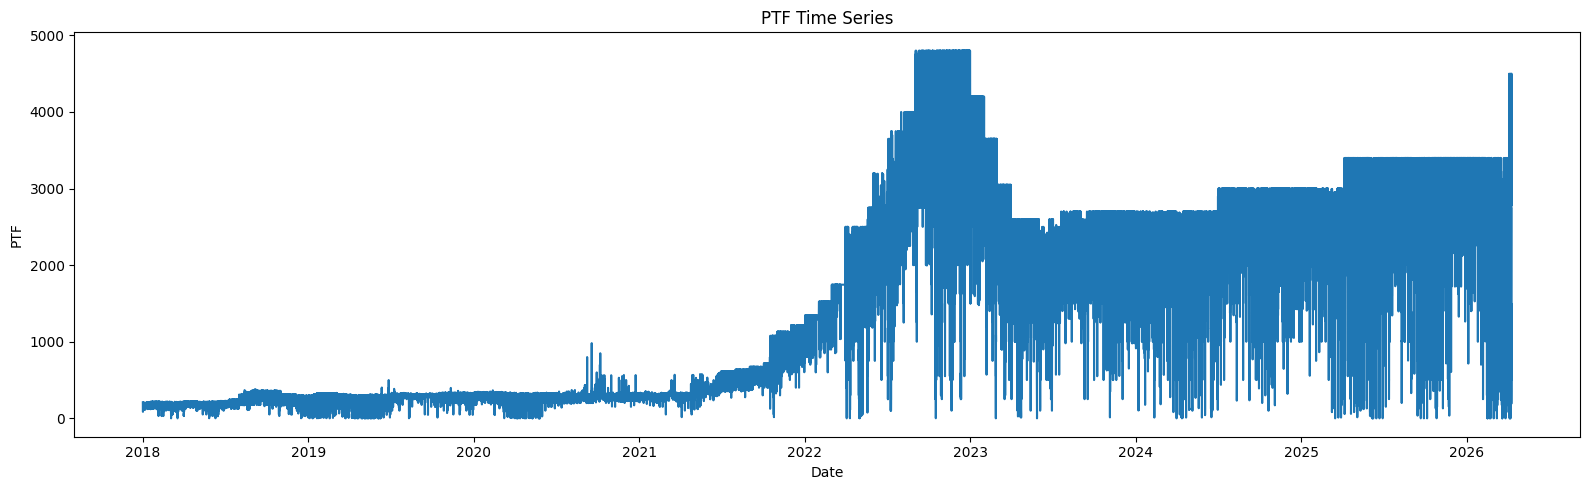

In [31]:
plt.figure(figsize=(16, 5))
plt.plot(df["date"], df["ptf"])
plt.title("PTF Time Series")
plt.xlabel("Date")
plt.ylabel("PTF")
plt.tight_layout()
plt.show()

In [32]:
df["ptf"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

count    72504.000000
mean      1378.258260
std       1219.884872
min          0.000000
1%          13.922100
5%         164.210000
25%        303.850000
50%        913.825000
75%       2448.280000
95%       3400.000000
99%       4499.990000
max       4800.000000
Name: ptf, dtype: float64

## Box plot for outlier inspection

A box plot provides a compact summary of the distribution and makes extreme observations easier to spot.

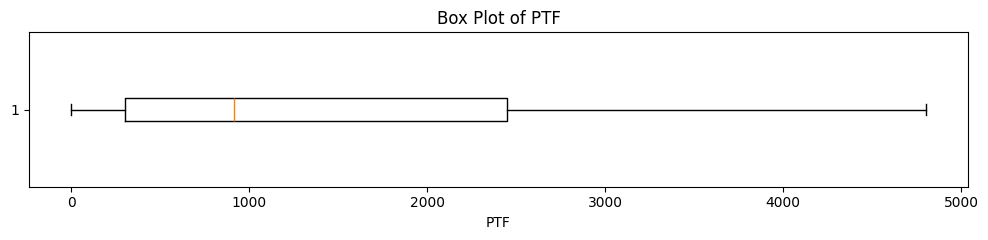

In [33]:
plt.figure(figsize=(10, 2.5))
plt.boxplot(df["ptf"], vert=False)
plt.title("Box Plot of PTF")
plt.xlabel("PTF")
plt.tight_layout()
plt.show()

## Create calendar-based helper columns

These columns are useful both for analysis and later feature engineering.

In [34]:
eda_df = df.copy()

eda_df["hour"] = eda_df["date"].dt.hour
eda_df["day_of_week"] = eda_df["date"].dt.dayofweek
eda_df["day_name"] = eda_df["date"].dt.day_name()
eda_df["month"] = eda_df["date"].dt.month
eda_df["month_name"] = eda_df["date"].dt.month_name()
eda_df["year"] = eda_df["date"].dt.year
eda_df["is_weekend"] = eda_df["day_of_week"].isin([5, 6]).astype(int)

eda_df.head()

,date,hour,ptf,priceusd,priceeur,_chunk_start,_chunk_end,year,month,day_of_week,day_name,month_name,is_weekend
0,2018-01-01 00:00:00+03:00,0,207.60,55.04,45.97,2018-01-01,2018-01-07,2018,1,0,Monday,January,0
1,2018-01-01 01:00:00+03:00,1,205.34,54.44,45.47,2018-01-01,2018-01-07,2018,1,0,Monday,January,0
2,2018-01-01 02:00:00+03:00,2,164.94,43.73,36.53,2018-01-01,2018-01-07,2018,1,0,Monday,January,0
3,2018-01-01 03:00:00+03:00,3,154.52,40.97,34.22,2018-01-01,2018-01-07,2018,1,0,Monday,January,0
4,2018-01-01 04:00:00+03:00,4,112.64,29.86,24.95,2018-01-01,2018-01-07,2018,1,0,Monday,January,0


## Average PTF by hour of day

This analysis is important for identifying intraday seasonality.  
If a clear hourly pattern exists, hour-based features will likely be useful in the forecasting model.

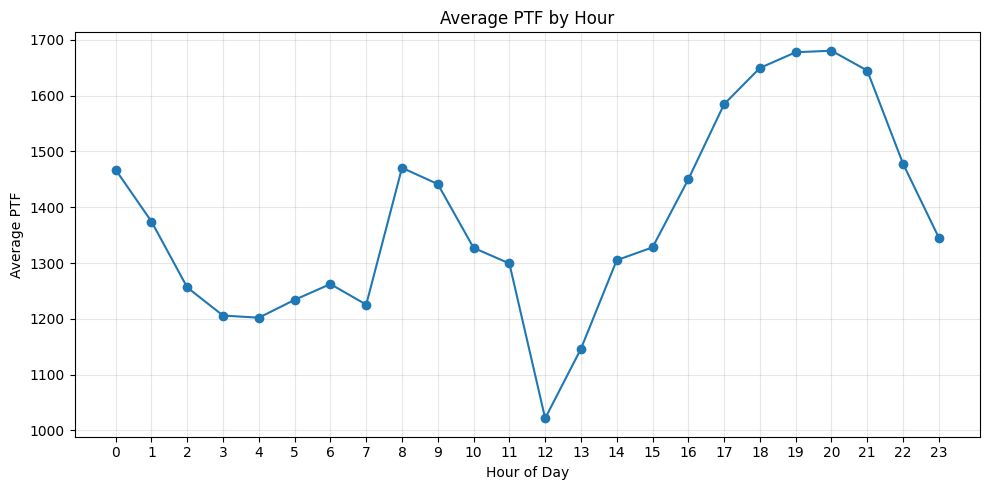

hour
0     1467.190622
1     1374.428514
2     1256.164743
3     1205.814863
4     1202.014128
5     1233.978957
6     1262.317438
7     1225.395290
8     1470.670622
9     1441.543873
10    1327.180477
11    1299.245349
12    1021.574263
13    1146.232877
14    1305.141072
15    1328.041370
16    1450.033525
17    1584.705038
18    1649.676107
19    1677.886882
20    1680.615813
21    1644.975068
22    1477.978199
23    1345.393148
Name: ptf, dtype: float64

In [35]:
hourly_mean = eda_df.groupby("hour")["ptf"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_mean.index, hourly_mean.values, marker="o")
plt.title("Average PTF by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average PTF")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

hourly_mean

## Average PTF by day of week

This step reveals weekly structure and helps determine whether weekday/weekend features may be informative.

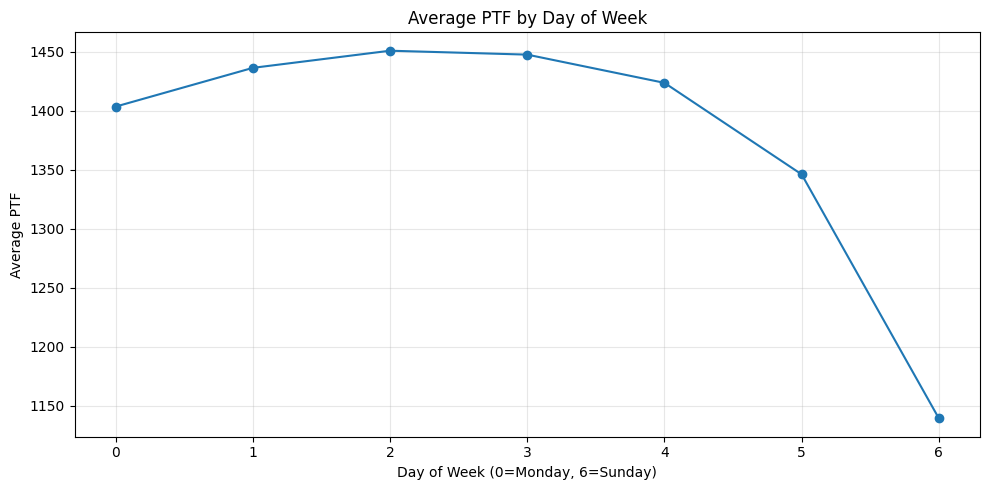

day_name
Monday       1403.497782
Tuesday      1436.318669
Wednesday    1450.835139
Thursday     1447.518647
Friday       1423.605073
Saturday     1346.093823
Sunday       1139.416326
Name: ptf, dtype: float64

In [36]:
dow_mean = eda_df.groupby("day_of_week")["ptf"].mean()

plt.figure(figsize=(10, 5))
plt.plot(dow_mean.index, dow_mean.values, marker="o")
plt.title("Average PTF by Day of Week")
plt.xlabel("Day of Week (0=Monday, 6=Sunday)")
plt.ylabel("Average PTF")
plt.xticks(range(7))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

dow_name_mean = eda_df.groupby("day_name")["ptf"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
dow_name_mean

## Weekend vs weekday comparison

This comparison helps quantify whether weekends behave differently from weekdays.

In [37]:
weekend_mean = eda_df.groupby("is_weekend")["ptf"].mean()
weekend_mean.index = ["Weekday", "Weekend"]
weekend_mean

Weekday    1432.359115
Weekend    1242.755075
Name: ptf, dtype: float64

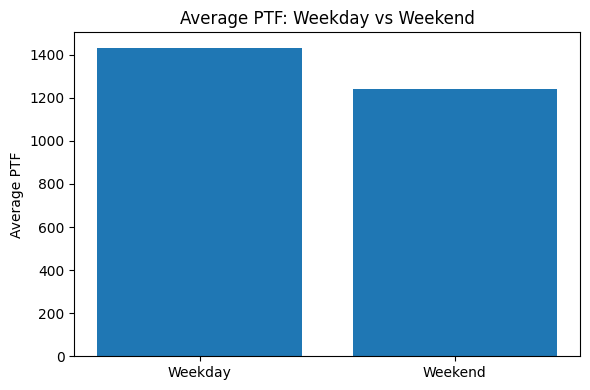

In [38]:
plt.figure(figsize=(6, 4))
plt.bar(weekend_mean.index, weekend_mean.values)
plt.title("Average PTF: Weekday vs Weekend")
plt.ylabel("Average PTF")
plt.tight_layout()
plt.show()

## Average PTF by month

Monthly analysis helps identify seasonal changes and long-term regime differences.

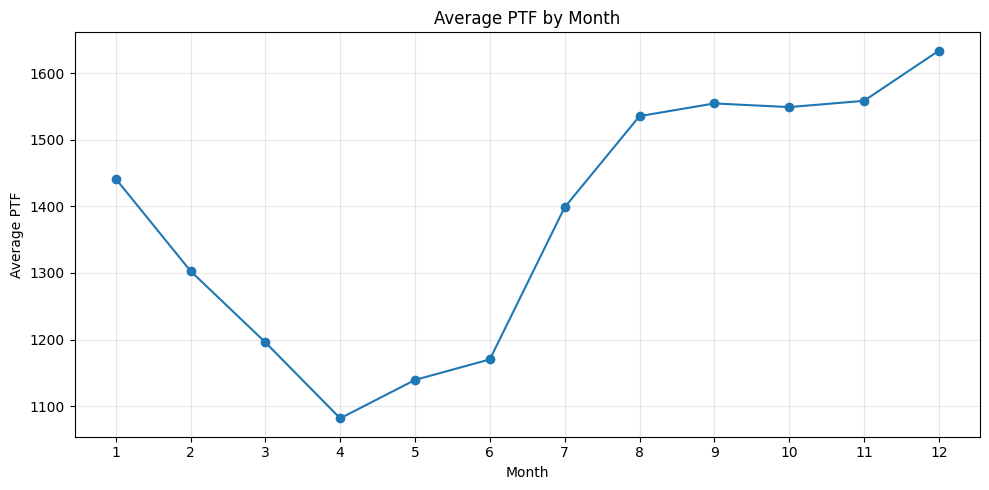

month
1     1441.592395
2     1302.997356
3     1195.825532
4     1081.714433
5     1139.399793
6     1170.222821
7     1398.646905
8     1535.526633
9     1554.558785
10    1549.074026
11    1558.501752
12    1633.733182
Name: ptf, dtype: float64

In [39]:
monthly_mean = eda_df.groupby("month")["ptf"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_mean.index, monthly_mean.values, marker="o")
plt.title("Average PTF by Month")
plt.xlabel("Month")
plt.ylabel("Average PTF")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

monthly_mean

## Monthly average through time

Instead of grouping all Januaries or all Februaries together, this view shows how the average PTF evolves month by month over the entire history.

C:\Users\berke\AppData\Local\Temp\ipykernel_20144\359831546.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ts = eda_df.set_index("date")["ptf"].resample("M").mean()


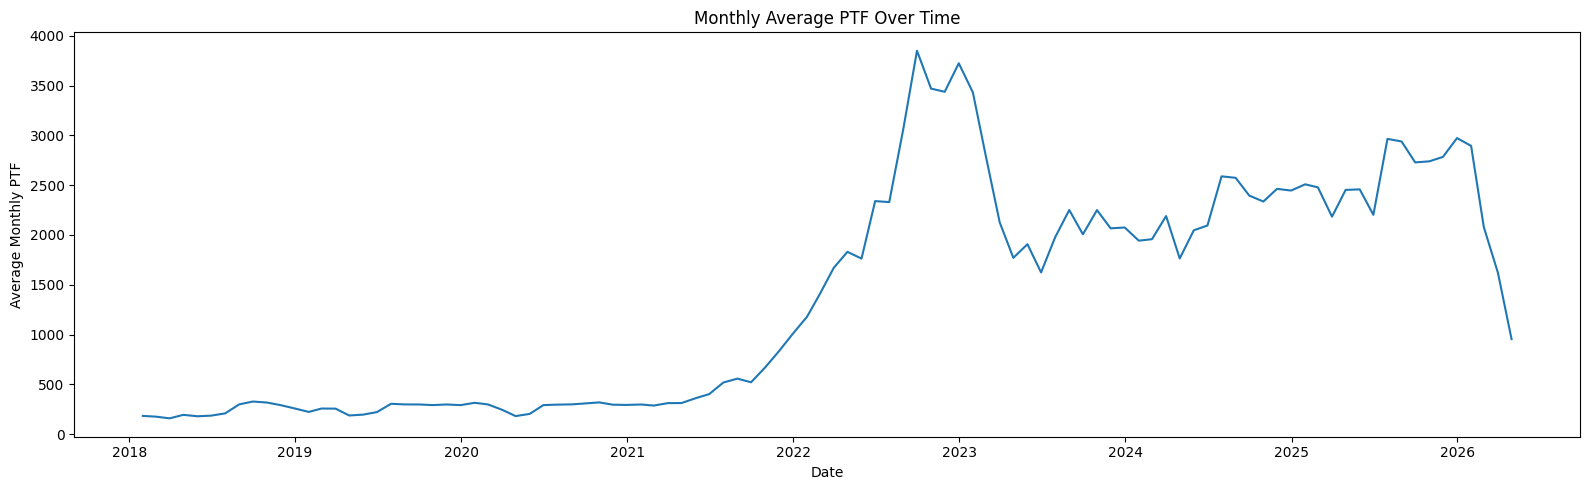

date
2025-05-31 00:00:00+03:00    2458.150565
2025-06-30 00:00:00+03:00    2202.225514
2025-07-31 00:00:00+03:00    2965.159153
2025-08-31 00:00:00+03:00    2939.238629
2025-09-30 00:00:00+03:00    2729.022403
2025-10-31 00:00:00+03:00    2739.500524
2025-11-30 00:00:00+03:00    2784.098125
2025-12-31 00:00:00+03:00    2973.042003
2026-01-31 00:00:00+03:00    2894.920699
2026-02-28 00:00:00+03:00    2078.195000
2026-03-31 00:00:00+03:00    1620.324288
2026-04-30 00:00:00+03:00     953.756713
Freq: ME, Name: ptf, dtype: float64

In [40]:
monthly_ts = eda_df.set_index("date")["ptf"].resample("M").mean()

plt.figure(figsize=(16, 5))
plt.plot(monthly_ts.index, monthly_ts.values)
plt.title("Monthly Average PTF Over Time")
plt.xlabel("Date")
plt.ylabel("Average Monthly PTF")
plt.tight_layout()
plt.show()

monthly_ts.tail(12)

## Rolling mean and rolling volatility

Rolling statistics help smooth short-term noise and reveal medium-term trend and variability.

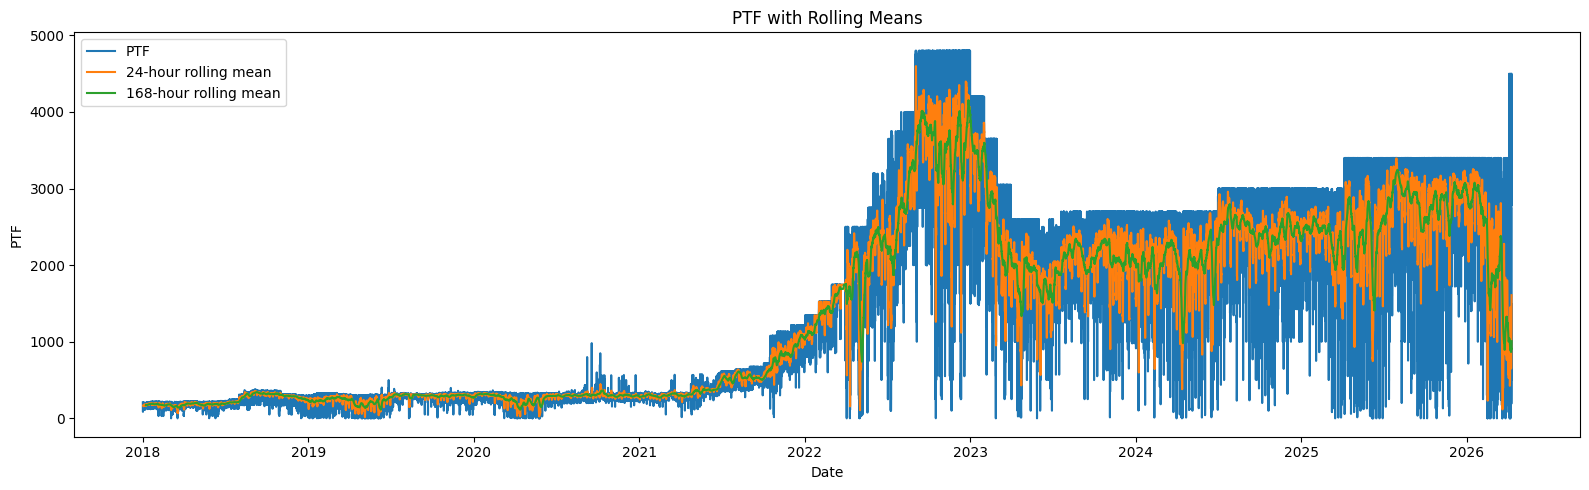

In [42]:
eda_df = eda_df.set_index("date")

eda_df["rolling_mean_24"] = eda_df["ptf"].rolling(24).mean()
eda_df["rolling_mean_168"] = eda_df["ptf"].rolling(168).mean()

plt.figure(figsize=(16, 5))
plt.plot(eda_df.index, eda_df["ptf"], label="PTF")
plt.plot(eda_df.index, eda_df["rolling_mean_24"], label="24-hour rolling mean")
plt.plot(eda_df.index, eda_df["rolling_mean_168"], label="168-hour rolling mean")
plt.title("PTF with Rolling Means")
plt.xlabel("Date")
plt.ylabel("PTF")
plt.legend()
plt.tight_layout()
plt.show()

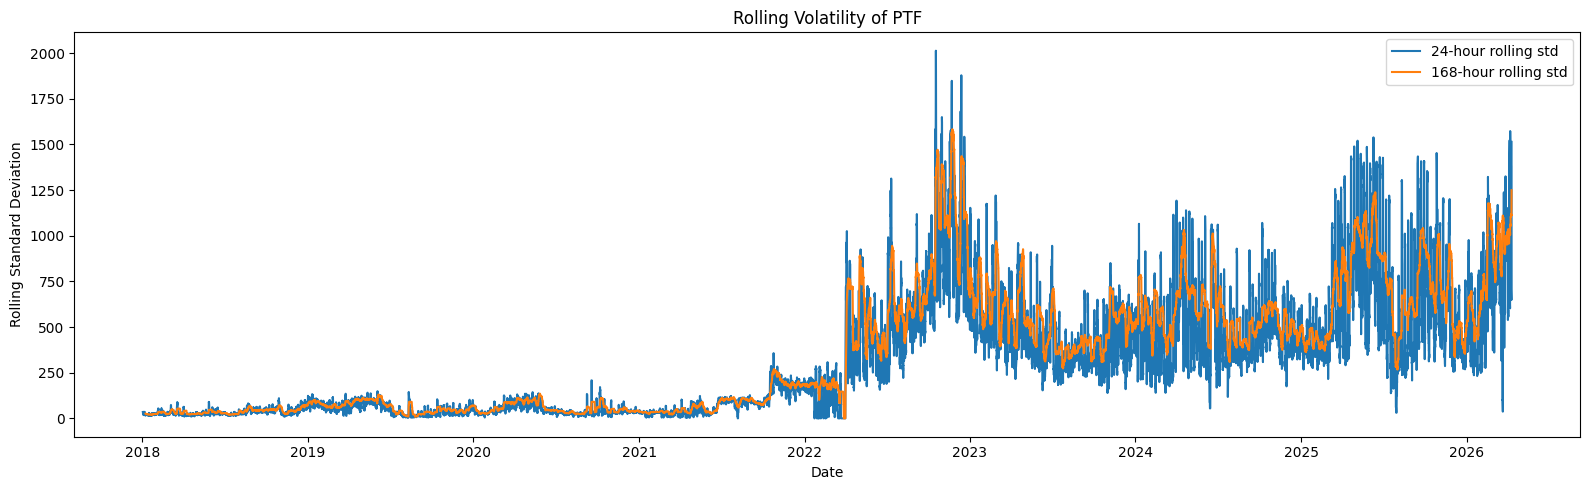

In [43]:
eda_df["rolling_std_24"] = eda_df["ptf"].rolling(24).std()
eda_df["rolling_std_168"] = eda_df["ptf"].rolling(168).std()

plt.figure(figsize=(16, 5))
plt.plot(eda_df.index, eda_df["rolling_std_24"], label="24-hour rolling std")
plt.plot(eda_df.index, eda_df["rolling_std_168"], label="168-hour rolling std")
plt.title("Rolling Volatility of PTF")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.legend()
plt.tight_layout()
plt.show()

## Lag relationship inspection

Scatter plots between the current value and lagged values help visually evaluate the predictive strength of past observations.

In [44]:
eda_df["lag_1"] = eda_df["ptf"].shift(1)
eda_df["lag_24"] = eda_df["ptf"].shift(24)
eda_df["lag_168"] = eda_df["ptf"].shift(168)

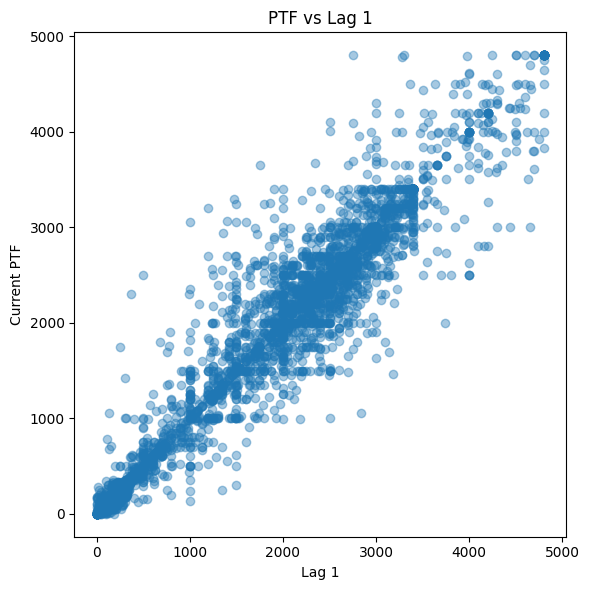

In [45]:
sample_df = eda_df[["ptf", "lag_1", "lag_24", "lag_168"]].dropna().sample(
    n=min(5000, len(eda_df.dropna())),
    random_state=42
)

plt.figure(figsize=(6, 6))
plt.scatter(sample_df["lag_1"], sample_df["ptf"], alpha=0.4)
plt.title("PTF vs Lag 1")
plt.xlabel("Lag 1")
plt.ylabel("Current PTF")
plt.tight_layout()
plt.show()

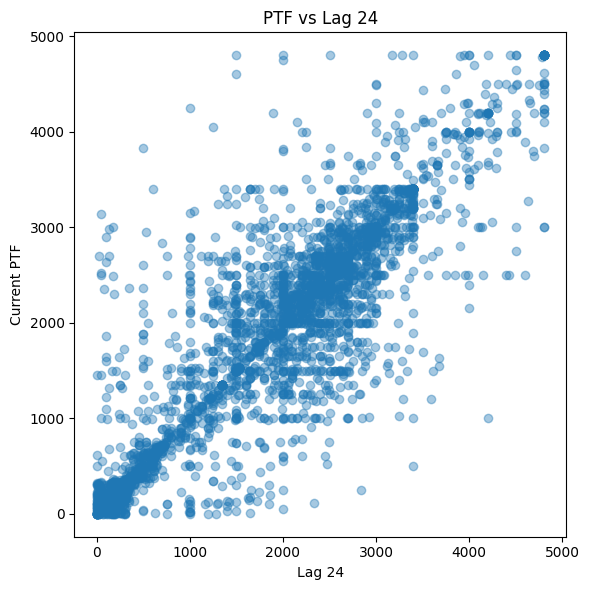

In [46]:
plt.figure(figsize=(6, 6))
plt.scatter(sample_df["lag_24"], sample_df["ptf"], alpha=0.4)
plt.title("PTF vs Lag 24")
plt.xlabel("Lag 24")
plt.ylabel("Current PTF")
plt.tight_layout()
plt.show()

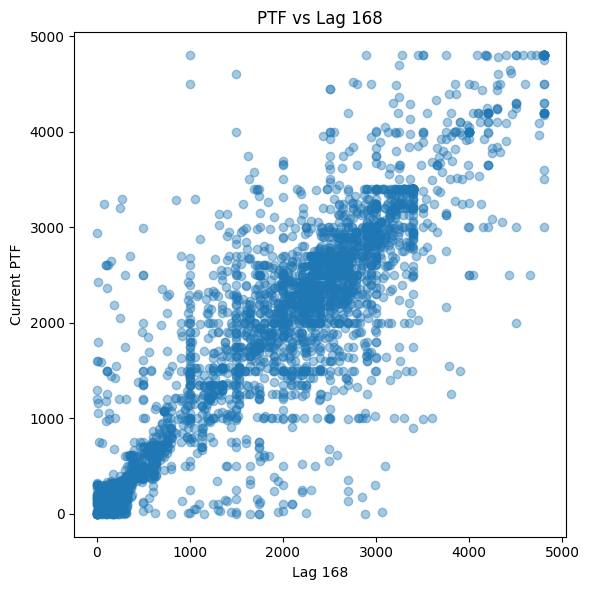

In [47]:
plt.figure(figsize=(6, 6))
plt.scatter(sample_df["lag_168"], sample_df["ptf"], alpha=0.4)
plt.title("PTF vs Lag 168")
plt.xlabel("Lag 168")
plt.ylabel("Current PTF")
plt.tight_layout()
plt.show()

## Correlation with lagged values

These correlations provide a quick numeric summary of how strongly current PTF is related to recent and seasonal lags.

In [48]:
lag_corrs = {
    "lag_1": eda_df["ptf"].corr(eda_df["lag_1"]),
    "lag_24": eda_df["ptf"].corr(eda_df["lag_24"]),
    "lag_168": eda_df["ptf"].corr(eda_df["lag_168"]),
}

lag_corrs

{'lag_1': np.float64(0.9689775641889606),
 'lag_24': np.float64(0.9244690873987649),
 'lag_168': np.float64(0.9233721841415148)}

## Autocorrelation analysis

Autocorrelation is one of the most important tools in time series EDA.

Strong peaks at specific lags, such as 24 or 168, suggest daily or weekly seasonality and justify corresponding lag-based features.

<Figure size 1400x500 with 0 Axes>

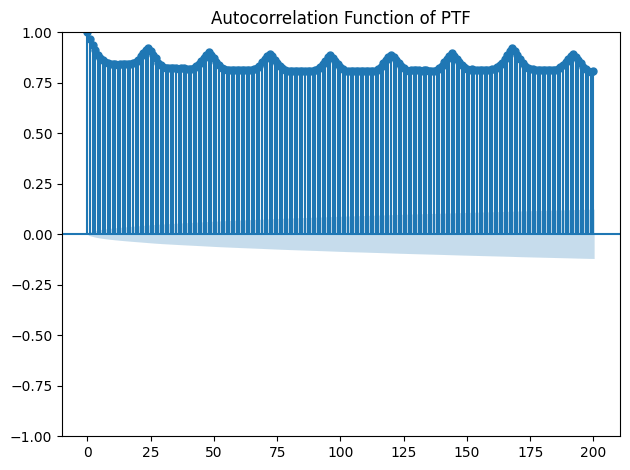

In [49]:
plt.figure(figsize=(14, 5))
plot_acf(eda_df["ptf"].dropna(), lags=200)
plt.title("Autocorrelation Function of PTF")
plt.tight_layout()
plt.show()

## Daily pattern example

Looking at a short recent window makes intraday patterns easier to observe visually.

C:\Users\berke\AppData\Local\Temp\ipykernel_20144\1044499652.py:1: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent_slice = eda_df.last("14D")


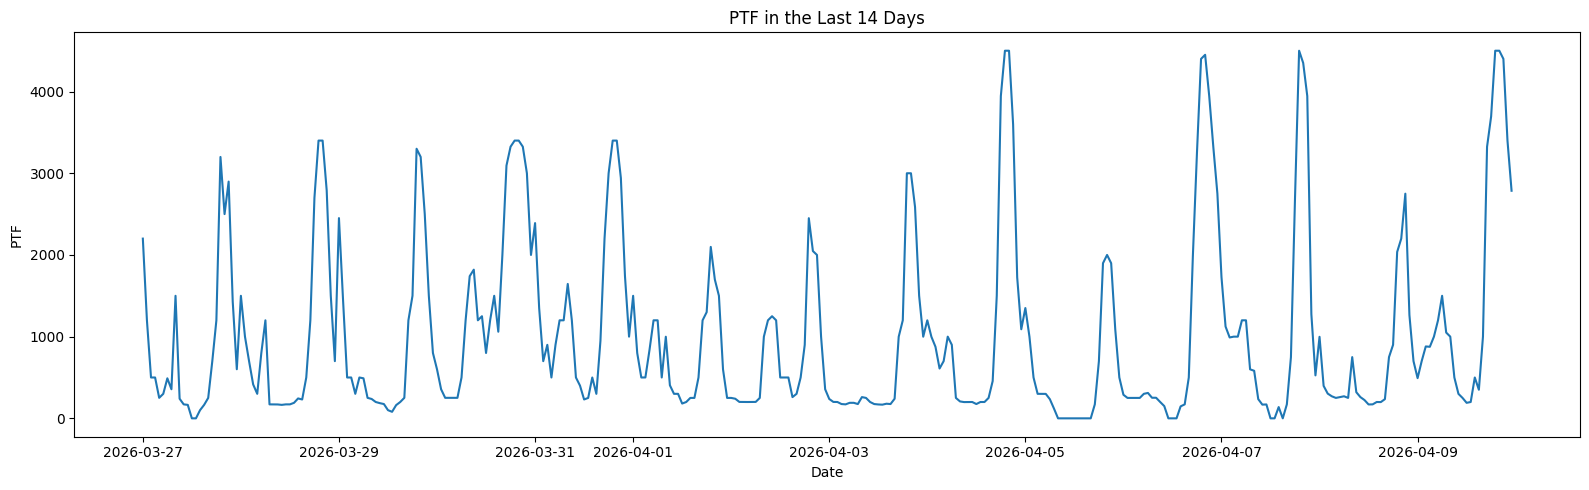

In [50]:
recent_slice = eda_df.last("14D")

plt.figure(figsize=(16, 5))
plt.plot(recent_slice.index, recent_slice["ptf"])
plt.title("PTF in the Last 14 Days")
plt.xlabel("Date")
plt.ylabel("PTF")
plt.tight_layout()
plt.show()

### Key observations

- The dataset is structured as an hourly time series.
- Missing timestamps should be checked carefully before modeling.
- PTF shows visible variability and occasional spikes.
- Hour-of-day patterns suggest strong intraday seasonality.
- Day-of-week effects indicate weekly structure.
- Lag relationships, especially at 24 and 168 hours, appear informative.
- Rolling statistics may be useful for capturing recent level and volatility.
- These observations support the use of:
  - calendar features
  - lag features
  - rolling window statistics
  - difference-based features